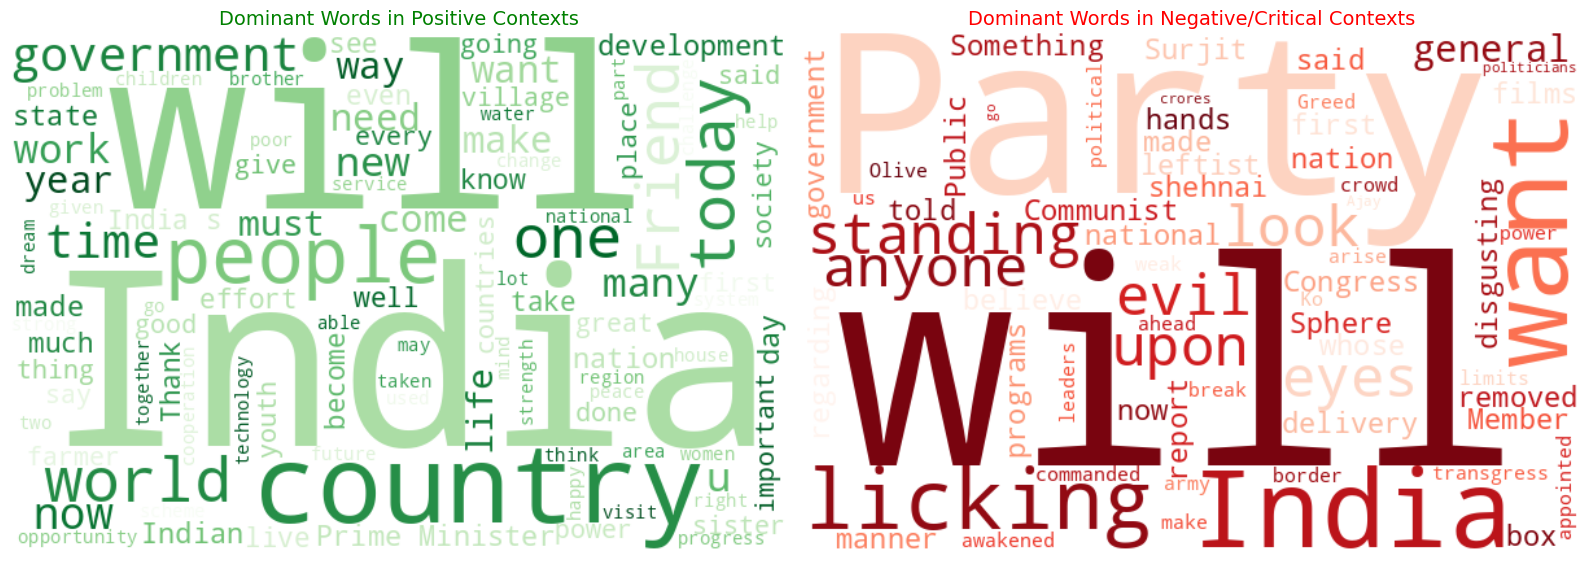

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from textblob import TextBlob

# 1. Load dataset
df = pd.read_csv('/content/cleaned_political_speeches.csv')

# 2. Extract Sentiment
df['polarity'] = df['text'].fillna('').apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# 3. Separate Text by Polarity Thresholds
positive_text = " ".join(df[df['polarity'] > 0.1]['text'].fillna('').astype(str))
negative_text = " ".join(df[df['polarity'] < -0.1]['text'].fillna('').astype(str))

# 4. Generate Clouds
wordcloud_pos = WordCloud(width=600, height=400, background_color='white', max_words=100, colormap='Greens').generate(positive_text)
wordcloud_neg = WordCloud(width=600, height=400, background_color='white', max_words=100, colormap='Reds').generate(negative_text)

# 5. Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(wordcloud_pos, interpolation='bilinear')
axes[0].set_title("Dominant Words in Positive Contexts", fontsize=14, color='green')
axes[0].axis('off')

axes[1].imshow(wordcloud_neg, interpolation='bilinear')
axes[1].set_title("Dominant Words in Negative/Critical Contexts", fontsize=14, color='red')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('/content/sentiment_wordclouds.png', dpi=300)
plt.show()

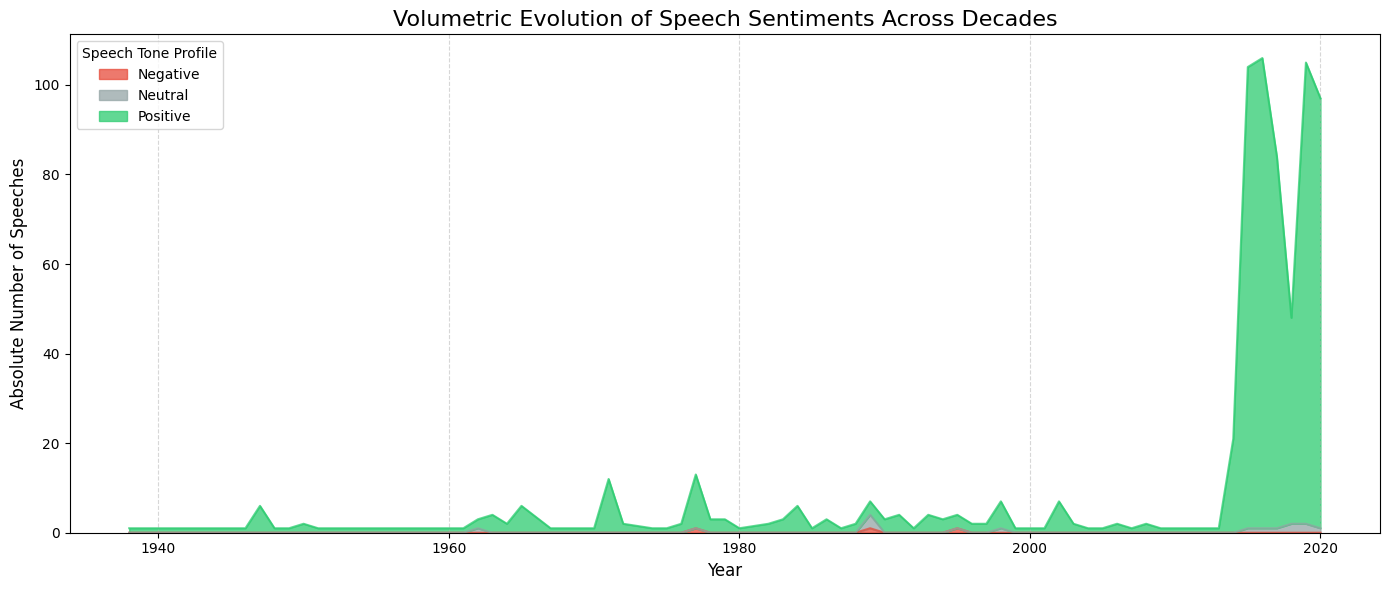

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob

# 1. Load Data
df = pd.read_csv('/content/cleaned_political_speeches.csv')
df['polarity'] = df['text'].fillna('').apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# 2. Categorize Sentiment
def categorize_sentiment(score):
    if score > 0.05: return 'Positive'
    elif score < -0.05: return 'Negative'
    return 'Neutral'

df['sentiment_category'] = df['polarity'].apply(categorize_sentiment)

# 3. Pivot and Group by Year
pivot_df = df.groupby(['year', 'sentiment_category']).size().unstack(fill_value=0)

# 4. Plot Area Chart
pivot_df.plot(kind='area', stacked=True, figsize=(14, 6), color=['#e74c3c', '#95a5a6', '#2ecc71'], alpha=0.75)
plt.title("Volumetric Evolution of Speech Sentiments Across Decades", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Absolute Number of Speeches", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(title="Speech Tone Profile")
plt.tight_layout()

plt.savefig('/content/speech_sentiment_volume_stack.png', dpi=300)
plt.show()

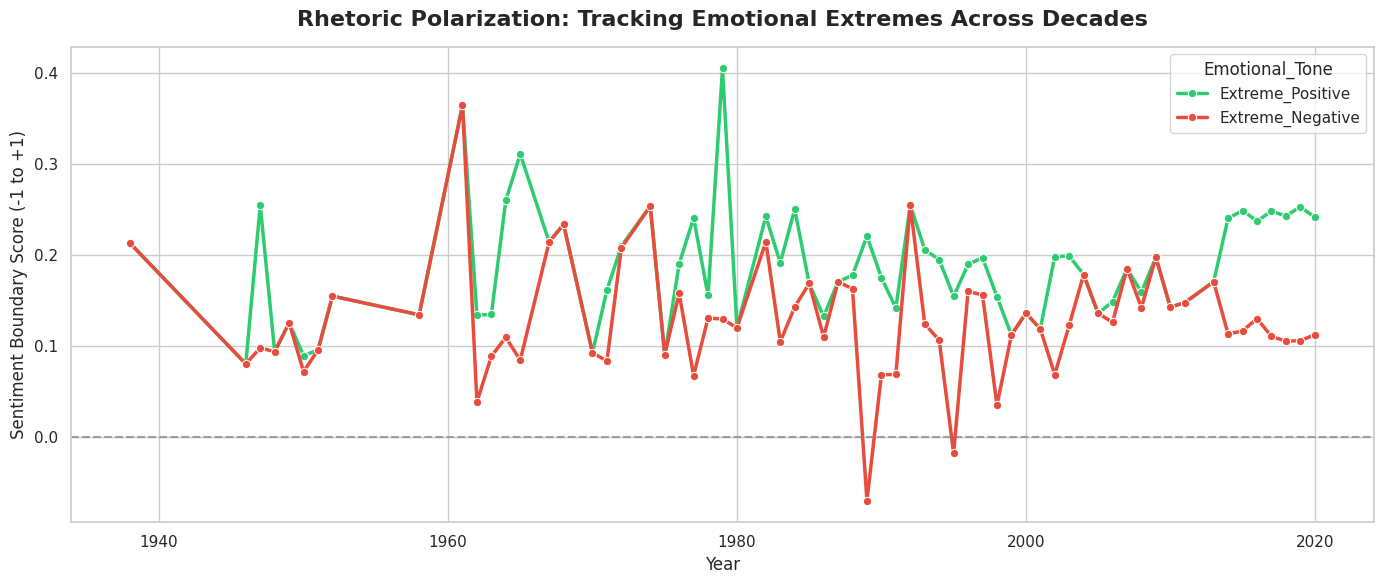

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob

# 1. Load data
df = pd.read_csv('/content/cleaned_political_speeches.csv')
df['polarity'] = df['text'].fillna('').apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# 2. Extract upper and lower emotional percentiles per year
# This grabs the 10% most negative and 10% most positive sentiments per year
sentiment_bounds = df.groupby('year')['polarity'].agg(
    Extreme_Positive=lambda x: np.percentile(x, 90),
    Extreme_Negative=lambda x: np.percentile(x, 10)
).reset_index()

# 3. Melt dataframe for Seaborn hue mapping
melted_df = sentiment_bounds.melt(id_vars='year', value_vars=['Extreme_Positive', 'Extreme_Negative'],
                                  var_name='Emotional_Tone', value_name='Polarity_Score')

# 4. Plot using Seaborn Lineplot
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=melted_df,
    x='year',
    y='Polarity_Score',
    hue='Emotional_Tone',
    palette={'Extreme_Positive': '#2ecc71', 'Extreme_Negative': '#e74c3c'},
    linewidth=2.5,
    marker='o'
)

plt.title("Rhetoric Polarization: Tracking Emotional Extremes Across Decades", fontsize=16, weight='bold', pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Sentiment Boundary Score (-1 to +1)", fontsize=12)
plt.axhline(0, color='gray', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('/content/seaborn_sentiment_divergence.png', dpi=300)
plt.show()

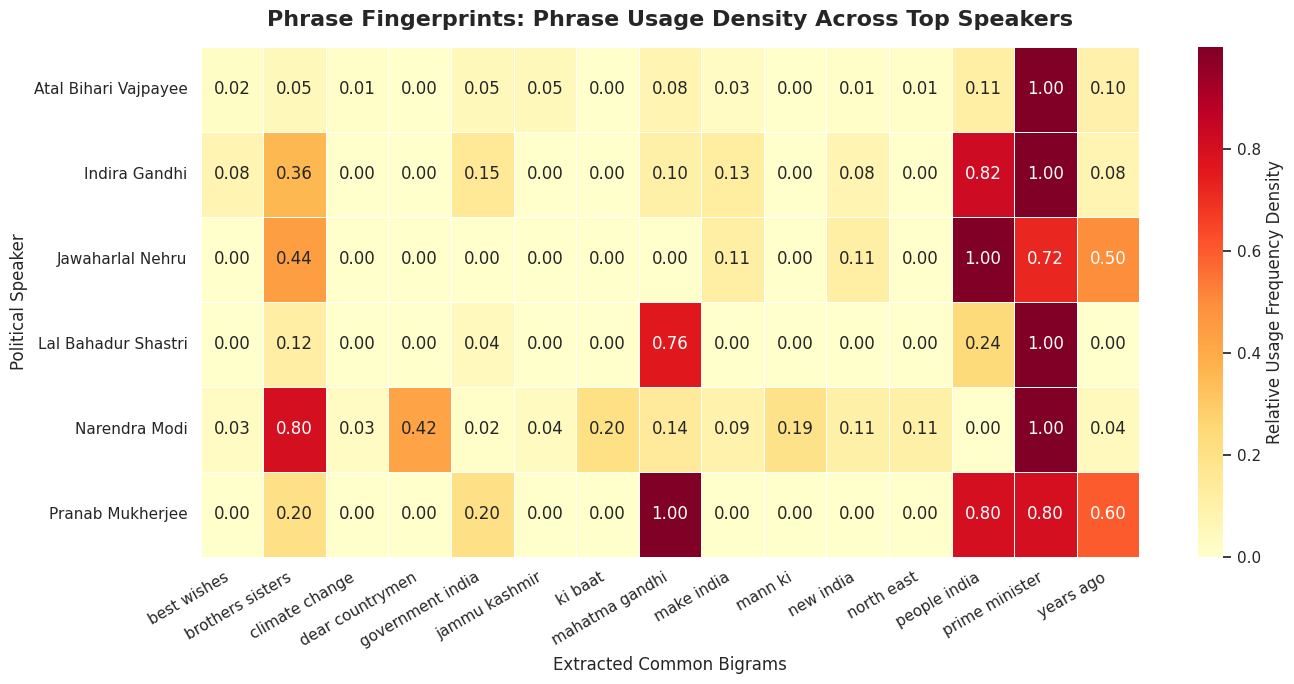

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# 1. Load Data
df = pd.read_csv('/content/cleaned_political_speeches.csv')

# 2. Get top 6 most frequent speakers
top_speakers = df['speaker'].value_counts().head(6).index
filtered_df = df[df['speaker'].isin(top_speakers)]

# 3. Vectorize text to find the top 15 most common Bigrams (2-word phrases)
vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=15, stop_words='english')
ngram_matrix = vectorizer.fit_transform(filtered_df['text'].fillna(''))
ngram_phrases = vectorizer.get_feature_names_out()

# 4. Convert to a DataFrame and group by speaker to get density matrix
density_df = pd.DataFrame(ngram_matrix.toarray(), columns=ngram_phrases)
density_df['speaker'] = filtered_df['speaker'].values
heatmap_data = density_df.groupby('speaker').sum()

# 5. Normalize rows (so differences in speech counts don't skew the colors)
heatmap_norm = heatmap_data.apply(lambda x: (x - x.min()) / (x.max() - x.min() + 1e-5), axis=1)

# 6. Plot Seaborn Heatmap with a clean configuration
plt.figure(figsize=(14, 7))
sns.heatmap(
    heatmap_norm,
    cmap="YlOrRd",
    linewidths=.5,
    cbar_kws={'label': 'Relative Usage Frequency Density'},
    annot=True,
    fmt=".2f"
)

plt.title("Phrase Fingerprints: Phrase Usage Density Across Top Speakers", fontsize=16, weight='bold', pad=15)
plt.xlabel("Extracted Common Bigrams", fontsize=12)
plt.ylabel("Political Speaker", fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

plt.savefig('/content/seaborn_phrase_heatmap.png', dpi=300)
plt.show()

/tmp/ipykernel_4387/3286048362.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


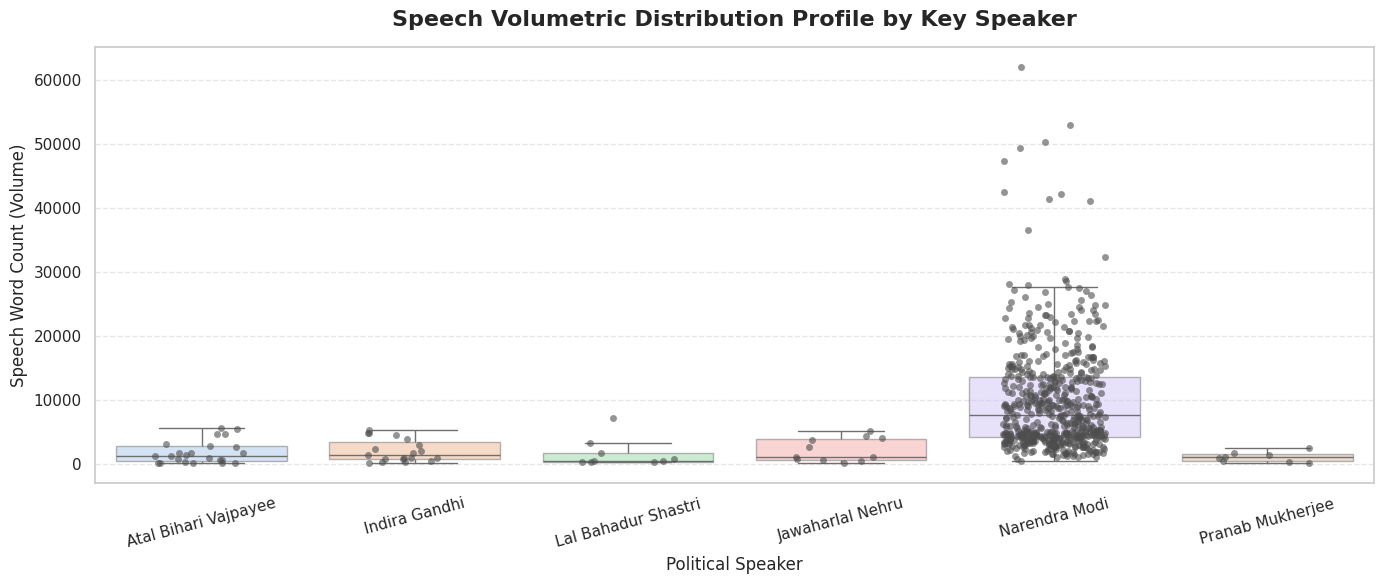

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv('/content/cleaned_political_speeches.csv')

# 2. Filter for top 6 speakers to keep the plot highly clean and legible
top_6_speakers = df['speaker'].value_counts().head(6).index
filtered_df = df[df['speaker'].isin(top_6_speakers)]

# 3. Initialize visual canvas
plt.figure(figsize=(14, 6))

# Draw the background statistical distributions
sns.boxplot(
    data=filtered_df,
    x='speaker',
    y='words',
    palette='pastel',
    boxprops=dict(alpha=0.5), # Make boxes semi-transparent
    showfliers=False          # Hide raw outliers so the stripplot can handle them cleanly
)

# Overlay the actual individual speech data points dynamically
sns.stripplot(
    data=filtered_df,
    x='speaker',
    y='words',
    size=5,
    color=".3",
    linewidth=0,
    alpha=0.6,
    jitter=0.24 # Distributes dots horizontally so they don't pile into a single solid line
)

plt.title("Speech Volumetric Distribution Profile by Key Speaker", fontsize=16, weight='bold', pad=15)
plt.xlabel("Political Speaker", fontsize=12)
plt.ylabel("Speech Word Count (Volume)", fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('/content/seaborn_speech_volume_distribution.png', dpi=300)
plt.show()